<a href="https://colab.research.google.com/github/birkenkrahe/ds2-26/blob/main/Copy_of_machine_learning_workflow_starter.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# The Machine Learning Workflow

A typical workflow consists of the following steps:

1. Define the problem
2. Collect data
3. Prepare data
4. Choose a model
5. Train the model
6. Evaluate the model
7. Use the model for prediction

This process is iterative. At any stage, it may be necessary to revisit earlier steps. At any stage, visualizations help greatly to clarify the picture.


## Common Issues

- Overfitting: model learns noise instead of pattern
- Underfitting: model is too simple to capture structure

Let's ask AI to illustrate this with an example.

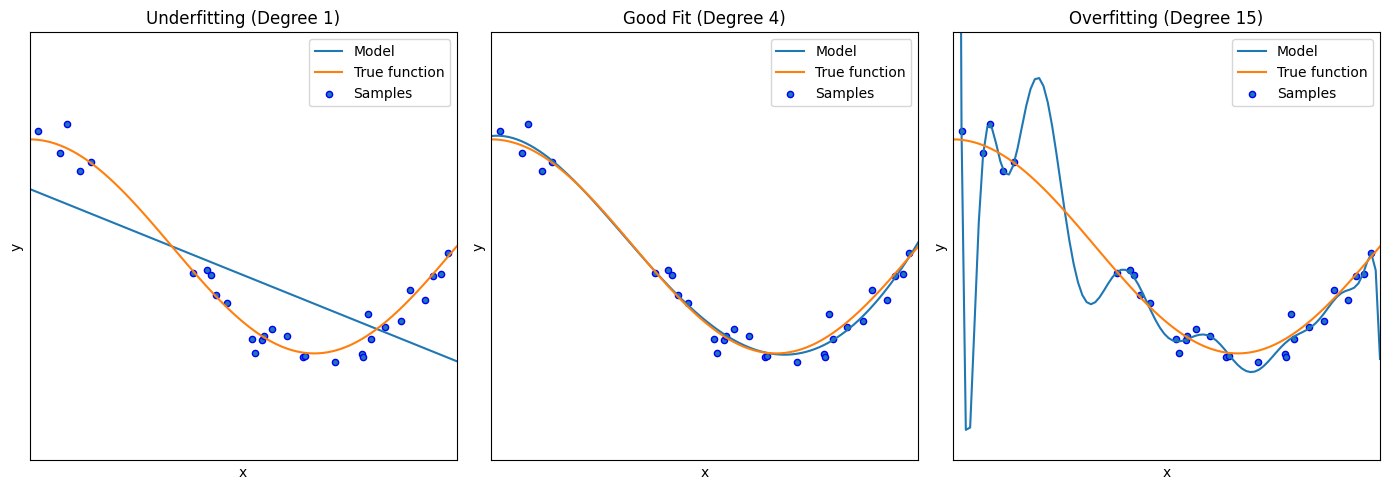

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import PolynomialFeatures
from sklearn.linear_model import LinearRegression

# Generate synthetic data
np.random.seed(0)
n_samples = 30
def true_fun(X):
    return np.cos(1.5 * np.pi * X)

X = np.sort(np.random.rand(n_samples))
y = true_fun(X) + np.random.randn(n_samples) * 0.1

# Degrees for Underfitting, Good fit, and Overfitting
degrees = [1, 4, 15]

plt.figure(figsize=(14, 5))
for i in range(len(degrees)):
    ax = plt.subplot(1, len(degrees), i + 1)
    plt.setp(ax, xticks=(), yticks=())

    polynomial_features = PolynomialFeatures(degree=degrees[i], include_bias=False)
    linear_regression = LinearRegression()
    pipeline = Pipeline([("polynomial_features", polynomial_features), ("linear_regression", linear_regression)])
    pipeline.fit(X[:, np.newaxis], y)

    X_test = np.linspace(0, 1, 100)
    plt.plot(X_test, pipeline.predict(X_test[:, np.newaxis]), label="Model")
    plt.plot(X_test, true_fun(X_test), label="True function")
    plt.scatter(X, y, edgecolor='b', s=20, label="Samples")

    plt.xlabel("x")
    plt.ylabel("y")
    plt.xlim((0, 1))
    plt.ylim((-2, 2))
    plt.legend(loc="best")

    titles = ["Underfitting (Degree 1)", "Good Fit (Degree 4)", "Overfitting (Degree 15)"]
    plt.title(titles[i])

plt.tight_layout()
plt.show()

# Fitting a linear model to data

The following example fits a linear model to data.

We want to predict how many hours of studying will give us which test score based on historical data - this is supervised learning since our historical data contain labels.

Begin with generating the data and visualizing.


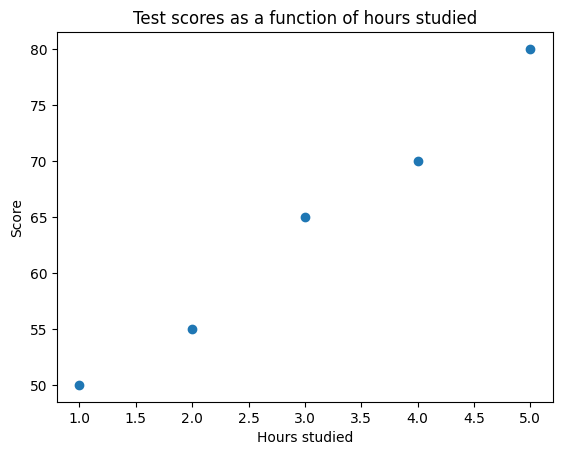

In [ ]:
import matplotlib.pyplot as plt # graphics functions
import numpy as np # mathematical functions

# generate data
hours = np.array([1,2,3,4,5])
score = np.array([50,55,65,70,80])

# plot data
plt.scatter(x=hours,y=score)
plt.xlabel("Hours studied")
plt.ylabel("Score")
plt.title("Test scores as a function of hours studied")
plt.savefig("plot.png")

Now we can try to fit a linear model to the data.

In [ ]:
# import ML library scikit-learn
from sklearn.linear_model import LinearRegression

# data transformation from vector to matrix
hours = np.array([1,2,3,4,5]).reshape(-1,1)

# model the data
model = LinearRegression() # create an empty model
model.fit(hours,score)

# get the output (model parameters)
print("Slope:", model.coef_[0])
print("Intercept:", model.intercept_)



Slope: 7.500000000000001
Intercept: 41.5


1. We have to import the ML library `scikit-learn`, and within the library, we get the `LinearRegression()` function from the `linear_model` module.

2. Many ML model require the input to be a 2D matrix. `reshape` changes the `shape` of the array without changing the data content.

In [ ]:
print(np.array([1,2,3,4,5])) # 1D vector
print(np.array([1,2,3,4,5]).reshape(-1,1)) # 2D matrix

[1 2 3 4 5]
[[1]
 [2]
 [3]
 [4]
 [5]]


3. We create an empty model instance with the `LinearRegression()` constructor.
4. `model.fit` trains the model: `hours` is our input matrix, and `score` is our output vector.
5. After the `.fit()`, the slope $\beta_0$ and the intercept $\beta_1$ are available. They define the learned function: `prediction = intercept + slope * x`
6. Numeric check: `hours[2]=3` corresponds to `score[2]=65`. for `x=3`, the model predicts:
$$
\hat{y} = 41.5 + 7.5\cdot 3 = 41.5 + 22.5 + 64.0
$$
There are 5 linear equations but only two unknowns - so mathematically, this system of linear equations is overdetermined.

# Making Predictions

The trained model can be used to make predictions:


In [ ]:
model.predict([[6]]) # 6 is a new data point

array([86.5])

The input `[[6]]` is one sample (outer list), and one feature (inner list) so its shape is (-1,1).

If you'd use `[6]` you would have an 1D array with shape `(1,)` which the scikit-learn library does accept.

# Visualizing the Model (Optional)


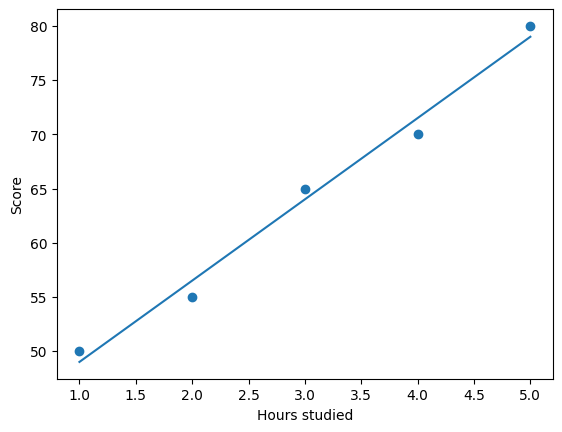

In [ ]:
import matplotlib.pyplot as plt # use plt as alias for the library

plt.scatter(hours, score)
plt.plot(hours, model.predict(hours))
plt.xlabel("Hours studied")
plt.ylabel("Score")
plt.show()

# PRACTICE Fitting a linear model

Use the following data:


Tasks:

1. Fit a linear model
2. Predict the value at 85$^\circ$F
3. Plot the data and fitted line
4. In one complete sentence at the end, explain what the fitted line tells us about the relationship between temperature and ice cream sales.

Use Gemini in Colab to complete these tasks.
